# Analyze fitness effects

Import Python modules

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import glob
from collections import defaultdict
import math
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')
import scipy
from Bio import SeqIO
from Bio.Seq import Seq

Read in data

In [2]:
# Read in fitness effects of amino-acid mutations
fitness_df = pd.read_csv('../results/aa_fitness_effects.csv', keep_default_na=False)
fitness_df = fitness_df[fitness_df['host'] == 'all']

# Read in data on fitness effects of synonymous mutations at a given site
site_syn_fitness_df = pd.read_csv('../results/sitewise_synonymous_fitness_effects.csv', keep_default_na=False)
site_syn_fitness_df = site_syn_fitness_df[site_syn_fitness_df['host'] == 'all']

Plot the distribution of effects

expected or actual count $\geq$ 10
N = 38399


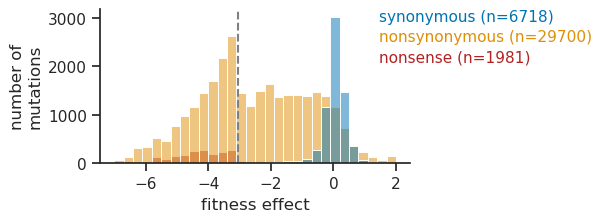

In [33]:
mut_class_colors = {
    'synonymous' : '#0173b2',
    'nonsynonymous' : '#de8f05',
    'nonsense' : 'firebrick',
}

count_threshold = 10
data = fitness_df[
    (fitness_df['expected_count'] >= count_threshold) |
    (fitness_df['actual_count'] >= count_threshold)
].copy()
print(f'expected or actual count $\geq$ {count_threshold}\nN = {len(data)}')
fitness_lod = np.log(0.5/(count_threshold+0.5))
data['delta_fitness'] = data['delta_fitness'].clip(upper=2, lower=-7)
plt.figure(figsize=(4,2))
ax = sns.histplot(
    x='delta_fitness', data=data, bins=30,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors
)

# Annotate the number of mutations in each class
for (i, mut_class) in enumerate(['synonymous', 'nonsynonymous', 'nonsense']):
    count = (data['mut_class'] == mut_class).sum()
    median_fitness = data.loc[data['mut_class'] == mut_class, 'delta_fitness'].median()
    ax.text(
        0.9, 0.9-i*0.13, f'{mut_class} (n={count})', ha='left', va='bottom',
        color=mut_class_colors[mut_class], fontsize=11, transform=ax.transAxes,
    )

ax.get_legend().remove()
plt.axvline(fitness_lod, color='gray', linestyle='--')
plt.xlabel('fitness effect')
plt.ylabel('number of\nmutations')
# plt.title(f'expected or actual count $\geq$ {count_threshold}\nN = {len(data)}', y=1.05)
sns.despine()
plt.show()

Plot distributions of fitness effects as a function of gene.

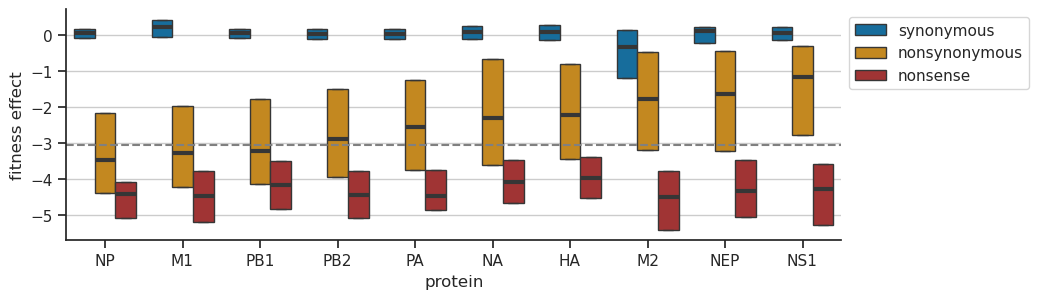

In [29]:
# Get data
count_threshold = 10
data = fitness_df[
    (fitness_df['expected_count'] >= count_threshold) |
    (fitness_df['actual_count'] >= count_threshold)
].copy()
fitness_lod = np.log(0.5/(count_threshold+0.5))

# TODO: remove
data['gene'] = data['gene'].apply(lambda x: x.upper())
data = data[data['gene'] != 'PB1;PB1-F2']

# Explode dataframe so that there is one row per mutation per gene
data['gene'] = data['gene'].str.split(';')
data['codon_site'] = data['codon_site'].str.split(';')
data = data.explode(['gene', 'codon_site'])

# Sort dataframe by median delta_fitness of nonsynonymous mutations
nonsynonymous_medians = (
    data[data['mut_class'] == 'nonsynonymous']
    .groupby('gene', as_index=False)['delta_fitness']
    .median()
    .sort_values('delta_fitness')
    .rename(columns={'delta_fitness':'median_nonsyn_fitness'})
)
data = (
    data
    .merge(nonsynonymous_medians)
    .sort_values('median_nonsyn_fitness', ascending=True)
)

# Plot data
plt.figure(figsize=[10,3])
sns.boxplot(
    x='gene', y='delta_fitness', data=data,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors,
    medianprops={"linewidth": 3}, showfliers=False, whis=(50,50)
)
plt.axhline(fitness_lod, color='gray', linestyle='--')
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1,1))
plt.xlabel('protein')
plt.ylabel('fitness effect')
sns.despine()
plt.show()

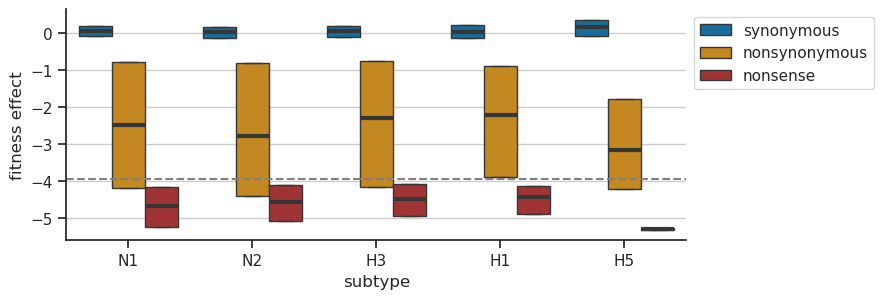

In [21]:
# Get data for HA/NA subtypes with at least 100 mutations with estimated fitness effects
ha_na_data = data[data['gene'].isin(['HA', 'NA'])].copy()
subtype_counts = ha_na_data['subtype'].value_counts()
subtypes_to_include = subtype_counts[subtype_counts >= 100].index
ha_na_data = ha_na_data[ha_na_data['subtype'].isin(subtypes_to_include)]

# Plot distributions for different HA and NA subtypes
plt.figure(figsize=[8,3])
sns.boxplot(
    x='subtype', y='delta_fitness', data=ha_na_data,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors,
    medianprops={"linewidth": 3}, showfliers=False, whis=(50,50)
)
plt.axhline(fitness_lod, color='gray', linestyle='--')
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel('fitness effect')
sns.despine()
plt.show()

Examine the fitness effects of synonymous mutation across the genome.

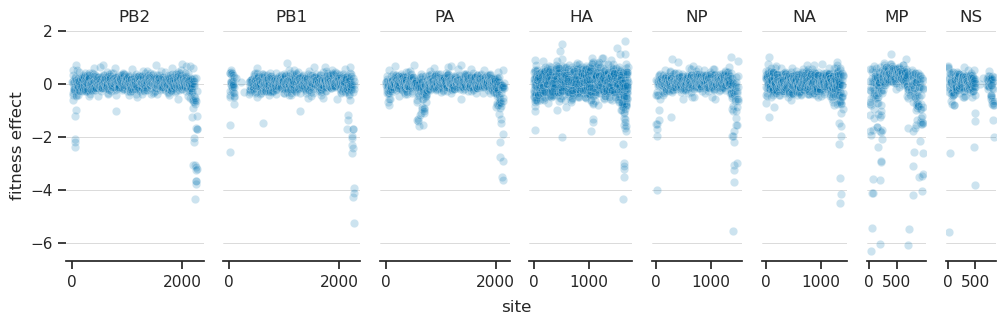

In [6]:
# Get data
count_threshold = 25
syn_data = site_syn_fitness_df[
    site_syn_fitness_df['expected_count'] >= count_threshold
].copy()

# Get width ratios for plotting segments
segments = ['PB2', 'PB1', 'PA', 'HA', 'NP', 'NA', 'MP', 'NS']
width_ratios = []
for segment in segments:
    # TODO: update with more accurate width ratios
    data = site_syn_fitness_df[site_syn_fitness_df['segment'] == segment]
    width_ratios.append(data['site'].max())

# Plot data
(fig, axs) = plt.subplots(
    ncols=len(segments), sharey=True, figsize=[12, 3],
    gridspec_kw={'width_ratios': width_ratios}
)
for (i, segment) in enumerate(segments):
    data = syn_data[(syn_data['segment'] == segment)]
    sns.scatterplot(
        x='site', y='delta_fitness', data=data, ax=axs[i], alpha=0.2,
        color=mut_class_colors['synonymous']
    )
    axs[i].grid(axis='y', which='both', lw=0.5)
    axs[i].set(title=segment, xlabel='')
    if i > 0:
        axs[i].tick_params(axis='y', which='both', left=False, labelleft=False)
    if segment in ['MP', 'NS']:
        axs[i].set(xticks=[0, 500])
    sns.despine(left=True, ax=axs[i])

axs[0].set(ylabel='fitness effect')
fig.text(0.5, -0.06, 'site', ha='center')
plt.show()

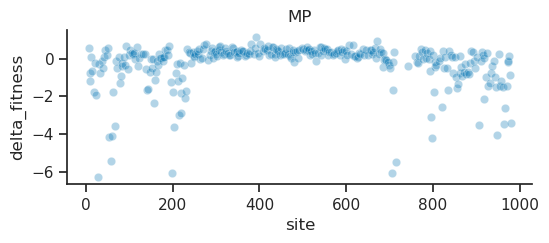

In [7]:
segment = 'MP'
data = syn_data[(syn_data['segment'] == segment)]
plt.figure(figsize=[6,2])
sns.scatterplot(x='site', y='delta_fitness', data=data, alpha=0.3)
plt.title(segment)
sns.despine()
plt.show()

## Compare estimated fitness effects to experimentally measured DMS data

Read in data on HA.

In [8]:
# Get fitness data
count_threshold_dms_comparison = 25
ha_fitness_data = fitness_df[
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['gene'] == 'HA') &
    (fitness_df['subtype'] == 'H3')
].copy()
ha_fitness_data['codon_site'] = ha_fitness_data['codon_site'].astype(int)

# Read in processed DMS data and merge with fitness data
ha_dms_data = pd.read_csv('../results/dms_data/Yu_HA/processed_dms_data.csv')
ha_dms_data = (
    ha_dms_data
    .rename(columns={'tree_reference_site' : 'codon_site'})
    .merge(ha_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(ha_dms_data))
print('N sites with data:', ha_dms_data['codon_site'].nunique())
ha_dms_data.head()

N muts with data: 1329
N sites with data: 503


,site,wt_aa,mut_aa,sera_escape,dms_effect,pH_stability,sequential_site,n_nt_changes,codon_site,reference_site,sequential_wt,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
0,1,Q,K,0.04918,-0.11150,0.001008,1,1,17,1,Q,all,H3,HA,HA,Q17K,nonsynonymous,53,41.625490,0.239029
1,1,Q,R,-0.19230,-0.88610,0.012610,1,1,17,1,Q,all,H3,HA,HA,Q17R,nonsynonymous,18,45.669259,-0.914543
2,2,K,E,-0.06889,-0.31980,0.050210,2,1,18,2,K,all,H3,HA,HA,K18E,nonsynonymous,75,78.135229,-0.040687
3,2,K,R,-0.10240,-0.61280,0.060580,2,1,18,2,K,all,H3,HA,HA,K18R,nonsynonymous,63,78.280932,-0.215631
4,3,I,M,-0.01625,0.07985,0.028840,3,1,19,3,I,all,H3,HA,HA,I19M,nonsynonymous,40,56.919235,-0.349077


Read in data for NP.

In [9]:
# Get fitness data
np_fitness_data = fitness_df[
    (fitness_df['gene'] == 'NP') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()
np_fitness_data['codon_site'] = np_fitness_data['codon_site'].astype(int)

# Read in data and merge with fitness data. The sites are indexed in the exact same way.
np_dms_data = (
    pd.read_csv('../results/dms_data/Bloom_NP/processed_dms_data.csv')
    .rename(columns={'site':'codon_site'})
    .merge(np_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(np_dms_data))
print('N sites with data:', np_dms_data['codon_site'].nunique())
np_dms_data

N muts with data: 1848
N sites with data: 485


,codon_site,wt_aa,mut_aa,preference,wt_preference,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
691,1,M,K,0.038531,0.391903,-2.319554,all,all,NP,NP,M1K,nonsynonymous,0,39.492699,-4.381844
1501,1,M,T,0.032492,0.391903,-2.490014,all,all,NP,NP,M1T,nonsynonymous,0,128.139409,-5.550160
547,1,M,I,0.023434,0.391903,-2.816809,all,all,NP,NP,M1I,nonsynonymous,0,354.776488,-6.566044
1229,1,M,R,0.028061,0.391903,-2.636616,all,all,NP,NP,M1R,nonsynonymous,0,25.209237,-3.939998
183,2,A,E,0.015231,0.753436,-3.901298,all,all,NP,NP,A2E,nonsynonymous,4,160.768583,-3.578994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1632,498,N,T,0.063578,0.088315,-0.328635,all,all,NP,NP,N498T,nonsynonymous,3,28.448872,-2.112768
182,498,N,D,0.001553,0.088315,-4.040906,all,all,NP,NP,N498D,nonsynonymous,6,92.099892,-2.656486
847,498,N,K,0.276824,0.088315,1.142474,all,all,NP,NP,N498K,nonsynonymous,12,40.799923,-1.195132
1500,498,N,S,0.029940,0.088315,-1.081722,all,all,NP,NP,N498S,nonsynonymous,238,187.677823,0.236982


Read in data for PB2.

In [10]:
# Get fitness data
fitness_data = fitness_df[
    (fitness_df['gene'] == 'PB2') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()
fitness_data['codon_site'] = fitness_data['codon_site'].astype(int)

# Read in the DMS data and merge with the fitness data
pb2_dms_data = (
    pd.read_csv('../data/dms_data/Soh_PB2/elife-45079-fig2-data1-v1.csv')
    .rename(columns={
        'site':'codon_site',
        'wildtype' : 'wt_aa', 
        'mutation' : 'mut_aa',
        'log2effectA549': 'dms_effect'
    })
    .merge(fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(pb2_dms_data))
print('N sites with data:', pb2_dms_data['codon_site'].nunique())
pb2_dms_data.head()

N muts with data: 2617
N sites with data: 757


,codon_site,wt_aa,mut_aa,prefA549,prefCCL141,log2prefA549,log2prefCCL141,effectA549,effectCCL141,dms_effect,...,Experimentally adaptive in,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
784,1,M,I,0.051935,0.048641,-4.267144,-4.361682,0.105989,0.134303,-3.238015,...,None,all,all,PB2,PB2,M1I,nonsynonymous,0,301.404830,-6.403259
2211,1,M,T,0.037434,0.052167,-4.739489,-4.260707,0.076396,0.144040,-3.710360,...,None,all,all,PB2,PB2,M1T,nonsynonymous,0,113.554573,-5.429824
1024,1,M,K,0.045065,0.042917,-4.471848,-4.542299,0.091968,0.118499,-3.442719,...,None,all,all,PB2,PB2,M1K,nonsynonymous,0,30.498361,-4.127081
173,2,E,D,0.050450,0.051871,-4.308996,-4.268940,0.272519,0.332758,-1.875570,...,None,all,all,PB2,PB2,E2D,nonsynonymous,16,31.363398,-0.658098
1025,2,E,K,0.023902,0.043219,-5.386741,-4.532198,0.129111,0.277256,-2.953314,...,None,all,all,PB2,PB2,E2K,nonsynonymous,10,415.625507,-3.679612


Read in data for NA.

In [11]:
# Get fitness data
na_fitness_data = fitness_df[
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['gene'] == 'NA') &
    (fitness_df['subtype'] == 'N1')
].copy()
na_fitness_data['codon_site'] = na_fitness_data['codon_site'].astype(int)

# Read in data and merge with fitness data. The sites are indexed in the exact same way.
na_dms_data = (
    pd.read_csv('../results/dms_data/Wang_NA/processed_dms_data.csv')
    .rename(columns={'tree_reference_site' : 'codon_site'})
    .merge(na_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(na_dms_data))
print('N sites with data:', na_dms_data['codon_site'].nunique())
na_dms_data

N muts with data: 870
N sites with data: 340


,dms_site,wt_aa,mut_aa,codon_site,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
0,7,I,M,7,-1.468916,all,N1,NA,NA,I7M,nonsynonymous,24,137.846936,-1.731091
1,8,I,L,8,-2.304362,all,N1,NA,NA,I8L,nonsynonymous,13,34.654456,-0.957062
2,8,I,V,8,-0.997490,all,N1,NA,NA,I8V,nonsynonymous,20,108.938782,-1.674940
3,8,I,T,8,-0.425550,all,N1,NA,NA,I8T,nonsynonymous,87,162.228780,-0.620446
4,8,I,M,8,-0.949175,all,N1,NA,NA,I8M,nonsynonymous,47,127.116537,-0.988300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864,406,F,L,407,-2.044494,all,N1,NA,NA,F407L,nonsynonymous,2,188.768188,-4.326874
866,406,F,S,407,-2.372462,all,N1,NA,NA,F407S,nonsynonymous,3,148.165623,-3.748937
868,407,W,R,408,-4.840724,all,N1,NA,NA,W408R,nonsynonymous,1,94.154104,-4.144764
867,407,W,R,408,-2.351493,all,N1,NA,NA,W408R,nonsynonymous,1,94.154104,-4.144764


Read in data for PB1.

In [12]:
# Get fitness data
pb1_fitness_data = fitness_df[
    (fitness_df['gene'] == 'PB1') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()
pb1_fitness_data['codon_site'] = pb1_fitness_data['codon_site'].astype(int)

# Read in processed DMS data and merge with fitness data
pb1_dms_data = (
    pd.read_csv('../results/dms_data/Li_PB1/processed_dms_data.csv')
    .rename(columns={'tree_reference_site': 'codon_site'})
    .merge(pb1_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(pb1_dms_data))
print('N sites with data:', pb1_dms_data['codon_site'].nunique())
pb1_dms_data.head()

N muts with data: 1023
N sites with data: 542


,dms_site,wt_aa,mut_aa,codon_site,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
0,1,M,I,1,-0.859333,all,all,PB1,PB1,M1I,nonsynonymous,0,245.906181,-6.200128
1,2,D,N,2,-0.940369,all,all,PB1,PB1,D2N,nonsynonymous,12,339.207669,-3.302357
2,2,D,E,2,-0.778942,all,all,PB1,PB1,D2E,nonsynonymous,4,43.716485,-2.285020
3,2,D,G,2,-0.755760,all,all,PB1,PB1,D2G,nonsynonymous,7,232.724077,-3.437097
4,4,N,D,4,0.060052,all,all,PB1,PB1,N4D,nonsynonymous,0,72.297218,-4.980825


Read in data for M1.

In [13]:
# Get fitness data
m1_fitness_data = fitness_df[
    (fitness_df['gene'] == 'M1') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()
m1_fitness_data['codon_site'] = m1_fitness_data['codon_site'].astype(int)

# Read in processed DMS data and merge with fitness data
m1_dms_data = (
    pd.read_csv('../results/dms_data/Hom_M1/processed_dms_data.csv')
    .rename(columns={'tree_reference_site': 'codon_site'})
    .merge(m1_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(m1_dms_data))
print('N sites with data:', m1_dms_data['codon_site'].nunique())
m1_dms_data.head()

N muts with data: 781
N sites with data: 227


,dms_site,wt_aa,mut_aa,codon_site,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
196,10,Y,H,10,-2.353206,all,all,MP,M1,Y10H,nonsynonymous,4,272.038657,-4.103703
29,10,Y,C,10,-2.614879,all,all,MP,M1,Y10C,nonsynonymous,1,315.785219,-5.351179
0,11,V,A,11,-0.696849,all,all,MP,M1,V11A,nonsynonymous,4,178.166182,-3.681442
153,11,V,G,11,-2.129542,all,all,MP,M1,V11G,nonsynonymous,7,31.608685,-1.454224
222,11,V,I,11,-2.755224,all,all,MP,M1,V11I,nonsynonymous,3,559.445689,-5.075077


Read in data for NEP.

In [14]:
# Get fitness data
# NEP overlaps NS1; gene, codon_site, wt_aa, and mut_aa are all stored as
# ';'-joined strings for overlapping mutations. Explode all four columns together
# to extract the NEP-specific values.
nep_fitness_data = fitness_df[
    fitness_df['gene'].str.contains('NEP') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()

for col in ['gene', 'codon_site', 'wt_aa', 'mut_aa']:
    nep_fitness_data[col] = nep_fitness_data[col].str.split(';')
nep_fitness_data = nep_fitness_data.explode(['gene', 'codon_site', 'wt_aa', 'mut_aa'])

# Keep only NEP rows where the mutation is nonsynonymous in NEP
nep_fitness_data = nep_fitness_data[
    (nep_fitness_data['gene'] == 'NEP') &
    (nep_fitness_data['wt_aa'] != nep_fitness_data['mut_aa'])
].copy()
nep_fitness_data['codon_site'] = nep_fitness_data['codon_site'].astype(int)

# Read in processed DMS data and merge with fitness data
nep_dms_data = (
    pd.read_csv('../results/dms_data/Teo_NEP/processed_dms_data.csv')
    .rename(columns={'tree_reference_site': 'codon_site'})
    .merge(nep_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(nep_dms_data))
print('N sites with data:', nep_dms_data['codon_site'].nunique())
nep_dms_data.head()

N muts with data: 349
N sites with data: 106


,dms_site,wt_aa,mut_aa,codon_site,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
0,2,D,E,2,0.023601,all,all,NS,NEP,D2E;D2E,nonsynonymous,50,40.169105,0.216505
1,2,D,G,2,0.248671,all,all,NS,NEP,D2G;D2G,nonsynonymous,11,232.567983,-3.008983
2,2,D,N,2,0.404429,all,all,NS,NEP,D2N;D2N,nonsynonymous,152,385.087131,-0.927603
3,4,N,D,4,-0.465135,all,all,NS,NEP,N4D;N4D,nonsynonymous,13,80.764301,-1.795017
4,4,N,S,4,0.127127,all,all,NS,NEP,N4S;N4S,nonsynonymous,45,190.853928,-1.436412


0.15520818619607013


<Axes: xlabel='dms_effect', ylabel='delta_fitness'>

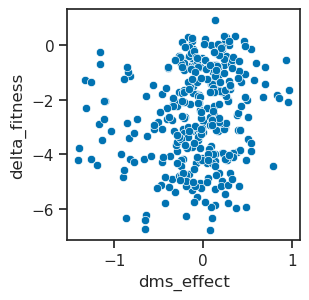

In [15]:
data = nep_dms_data # nep_dms_data[nep_dms_data['codon_site'].between(100,111)]
print(data['dms_effect'].corr(data['delta_fitness']))
plt.figure(figsize=[3,3])
sns.scatterplot(x='dms_effect', y='delta_fitness', data=data)

Summary plot comparing DMS effects and fitness effects

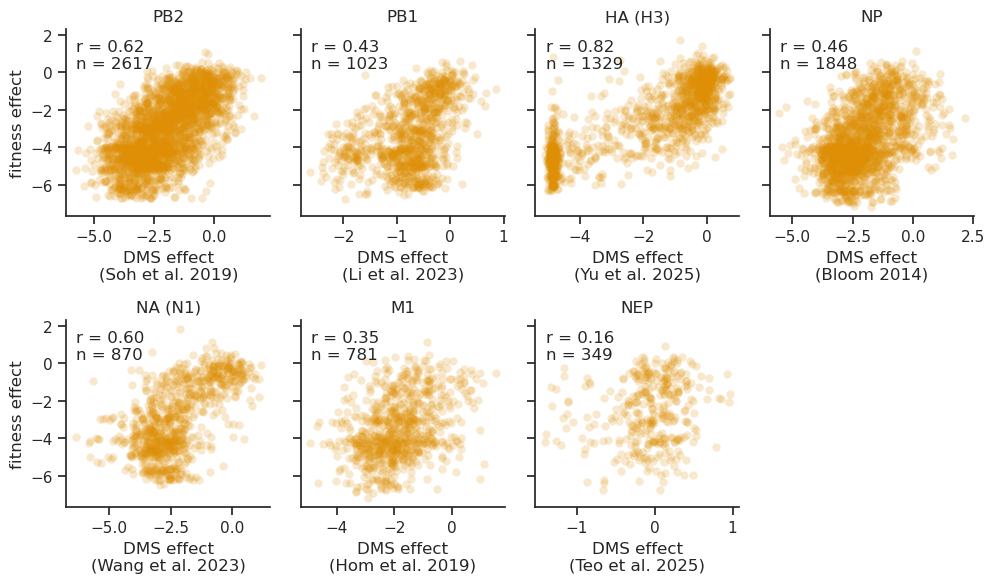

In [17]:
datasets = [
    ('PB2', pb2_dms_data),
    ('PB1', pb1_dms_data),
    ('HA (H3)',  ha_dms_data),
    ('NP',  np_dms_data),
    ('NA (N1)',  na_dms_data),
    ('M1',  m1_dms_data),
    ('NEP', nep_dms_data),
]
author_year = {
    'HA (H3)' : 'Yu et al. 2025',
    'NP' : 'Bloom 2014',
    'M1' : 'Hom et al. 2019',
    'NEP' : 'Teo et al. 2025',
    'PB1' : 'Li et al. 2023',
    'PB2' : 'Soh et al. 2019',
    'NA (N1)' : 'Wang et al. 2023',
}

fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(10, 6), sharey=True)
axs = axs.flatten()

fitness_lod = np.log(0.5/(count_threshold_dms_comparison+0.5))
for ax, (label, df) in zip(axs, datasets):
    r = df['dms_effect'].corr(df['delta_fitness'])
    n = len(df)
    sns.scatterplot(
        x='dms_effect', y='delta_fitness', data=df,
        c=mut_class_colors['nonsynonymous'], alpha=0.2, linewidth=0, ax=ax
    )
    # ax.axhline(fitness_lod, color='gray', linestyle='--')
    ax.annotate(f'r = {r:.2f}\nn = {n}', xy=(0.05, 0.95), xycoords='axes fraction', va='top')
    ax.set(
        title=label, xlabel=f'DMS effect\n({author_year[label]})',
        ylabel='fitness effect'
    )
    sns.despine(ax=ax)

# Hide the last plot
axs[-1].axis('off')

plt.tight_layout()
plt.show()

In [18]:
pb1_dms_data[
    (pb1_dms_data['delta_fitness'] < -4) &
    (pb1_dms_data['dms_effect'] > -1)
][['codon_site', 'wt_aa', 'mut_aa', 'dms_effect', 'delta_fitness']]

,codon_site,wt_aa,mut_aa,dms_effect,delta_fitness
0,1,M,I,-0.859333,-6.200128
4,4,N,D,0.060052,-4.980825
6,5,P,L,-0.664120,-4.052978
21,15,Q,R,-0.669634,-5.002051
24,17,A,T,-0.520483,-4.826272
...,...,...,...,...,...
963,725,D,E,-0.728328,-4.427692
964,725,D,G,-0.419209,-4.202411
982,732,S,P,-0.634946,-4.994284
1009,747,C,Y,-0.559514,-6.173734
